In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from arch import arch_model


Import took 39.3656 seconds


In [2]:
# load csv 
df = pd.read_csv('../data/btc_data.csv', index_col = 'Date', parse_dates = True)


print(df.index)




DatetimeIndex(['2018-01-31', '2018-02-01', '2018-02-02', '2018-02-03',
               '2018-02-04', '2018-02-05', '2018-02-06', '2018-02-07',
               '2018-02-08', '2018-02-09',
               ...
               '2024-12-21', '2024-12-22', '2024-12-23', '2024-12-24',
               '2024-12-25', '2024-12-26', '2024-12-27', '2024-12-28',
               '2024-12-29', '2024-12-30'],
              dtype='datetime64[us]', name='Date', length=2526, freq=None)


In [3]:
# Get log_returns 
returns = df['log_returns'] * 100

# Compile log_returns on Arch model
model = arch_model(returns, vol = "Garch", p = 1 , q = 1 )

# Fit
garch_fit = model.fit()
print(garch_fit.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 11458.293854312968
Iteration:      2,   Func. Count:     14,   Neg. LLF: 2912581.1729776063
Iteration:      3,   Func. Count:     21,   Neg. LLF: 6778.394545008401
Iteration:      4,   Func. Count:     27,   Neg. LLF: 6666.598926694901
Iteration:      5,   Func. Count:     33,   Neg. LLF: 6779.787205147393
Iteration:      6,   Func. Count:     39,   Neg. LLF: 15217.749960144136
Iteration:      7,   Func. Count:     45,   Neg. LLF: 6623.968790223501
Iteration:      8,   Func. Count:     50,   Neg. LLF: 6623.84637083143
Iteration:      9,   Func. Count:     55,   Neg. LLF: 6623.802109837094
Iteration:     10,   Func. Count:     60,   Neg. LLF: 6623.782404923464
Iteration:     11,   Func. Count:     65,   Neg. LLF: 6623.781824102052
Iteration:     12,   Func. Count:     70,   Neg. LLF: 6623.78164111111
Iteration:     13,   Func. Count:     75,   Neg. LLF: 6623.781638700961
Iteration:     14,   Func. Count:     79,   Neg. LLF: 6623.7816

Beta converged to 0.8496 -> Volatility is highly persistent 
Low p-value: 3.850 e-83 -> Past volatility is statistically significant predictor of future volatility
omega : 0.7467: Represents long run average variance contribution 
alpha converged 0.0947 -> Low , individual shocks don't have huge immediate impact

alpha + beta = 0.9423 -> Volatility shock decay slowly, volatility shocks persist 
*alpha + beta = 1 -> Volatility shocks never decay

In [4]:
#Splitting Train, Validation, Test Split
train = df.loc["2018-01-31":"2022-12-31"]
val = df.loc["2023-01-01":"2023-12-31"]
test = df.loc["2024-01-01":"2024-12-31"]

print(len(train), len(val), len(test))


1796 365 365


In [5]:
train_returns = train['log_returns'] *100
model = arch_model(train_returns, vol = "Garch", p = 1 , q = 1 )

garch_fit_train = model.fit()
print(garch_fit_train.summary)

Iteration:      1,   Func. Count:      6,   Neg. LLF: 9626.771347876313
Iteration:      2,   Func. Count:     13,   Neg. LLF: 5451.372753927555
Iteration:      3,   Func. Count:     19,   Neg. LLF: 5123.795939194395
Iteration:      4,   Func. Count:     25,   Neg. LLF: 5097.763196593549
Iteration:      5,   Func. Count:     32,   Neg. LLF: 5925.230288320515
Iteration:      6,   Func. Count:     40,   Neg. LLF: 4902.944905657774
Iteration:      7,   Func. Count:     46,   Neg. LLF: 4894.866866572001
Iteration:      8,   Func. Count:     51,   Neg. LLF: 4894.866639976015
Iteration:      9,   Func. Count:     56,   Neg. LLF: 4894.866636950025
Iteration:     10,   Func. Count:     60,   Neg. LLF: 4894.866636949663
Optimization terminated successfully    (Exit mode 0)
            Current function value: 4894.866636950025
            Iterations: 10
            Function evaluations: 60
            Gradient evaluations: 10
<bound method ARCHModelResult.summary of                      Constant 


omega = 1.1671 (increased from model that was trained with all values)
alpha = 0.0870 (lower alpha)
beta = 0.8375 (lower beta)
persistence: alpha + beta = 0.9245
only meaning ful increase was omega 

In [6]:
forecasts = []

for i in range(len(test)):
    cur_date = test.index[i]
    returns_till_now = df['log_returns'].loc[:cur_date] *100 # GARCH performs better when values are in percentages
    model = arch_model(returns_till_now, vol= 'Garch', p = 1, q = 1)
    daily_garch = model.fit()
    
    prediction = daily_garch.forecast(horizon = 1) #forecast() returns ARCHModelFrorecast object we need variance
    
    forecasts.append(prediction.variance.values[-1][0]) # Returns last row (most recent forecast) and first element as we forecasted only one step ahead
    
    

Iteration:      1,   Func. Count:      6,   Neg. LLF: 10152.430967983506
Iteration:      2,   Func. Count:     13,   Neg. LLF: 1175209.6619997753
Iteration:      3,   Func. Count:     20,   Neg. LLF: 5780.4149858857345
Iteration:      4,   Func. Count:     27,   Neg. LLF: 5856.640314187902
Iteration:      5,   Func. Count:     33,   Neg. LLF: 5841.018062738989
Iteration:      6,   Func. Count:     39,   Neg. LLF: 6616.827747631188
Iteration:      7,   Func. Count:     45,   Neg. LLF: 5767.08394102859
Iteration:      8,   Func. Count:     51,   Neg. LLF: 5734.974085129881
Iteration:      9,   Func. Count:     56,   Neg. LLF: 5734.920900577712
Iteration:     10,   Func. Count:     61,   Neg. LLF: 5734.919433878464
Iteration:     11,   Func. Count:     66,   Neg. LLF: 5734.9194279491185
Iteration:     12,   Func. Count:     71,   Neg. LLF: 5734.919426507102
Iteration:     13,   Func. Count:     75,   Neg. LLF: 5734.9194265070255
Optimization terminated successfully    (Exit mode 0)
      

In [7]:
#Evaluation 
print(len(forecasts))
print(forecasts[:5])
print(type(forecasts[0]))

365
[np.float64(8.459059352194043), np.float64(8.225150700111334), np.float64(10.169362799682006), np.float64(10.2545286101326), np.float64(9.48398474728483)]
<class 'numpy.float64'>


Forecasts outputted : [np.float64(8.459059352194043), np.float64(8.225150700111334), np.float64(10.169362799682006), np.float64(10.2545286101326), np.float64(9.48398474728483)]

As GARCH returns variance (sigma^2) and volatility is (sigma) we are getting a dialy volatility of sqrt(9) and sqrt(10) which is reasonable for bitcoin

In [8]:
#Extracting volatility from our predictions

garch_vol_forecast = np.sqrt(np.array(forecasts))/100

actual = test['volatility']
results = pd.DataFrame({'actual': actual, 'garch_forecast': garch_vol_forecast}, index = test.index)
print(results.head())

              actual  garch_forecast
Date                                
2024-01-01  0.024354        0.029084
2024-01-02  0.024436        0.028680
2024-01-03  0.024695        0.031889
2024-01-04  0.023673        0.032023
2024-01-05  0.023629        0.030796


MSE: Average of the sum of the differences between actual and predicted values squared
Measures Variance of the residuals
*Penalizes large errors more heavily than MAE due to squaring

MAE: Average of the sum of the differences between actual and predicted values (absolute value)
Measures average of the residuals in the dataset

Directional Accuracy: Ability of a forecasting model to correctly predict the direction of change in a time series relative to the last observation
Important as it determines whether our predictions accurately predicted increases or decreases

In [12]:
#Computing MSE and MAE 
from sklearn.metrics import mean_absolute_error, mean_squared_error

mse = mean_squared_error(results['actual'], results['garch_forecast'])
mae = mean_absolute_error(results['actual'], results['garch_forecast'])

print(f"MSE: {mse}")
print(f"MAE: {mae}")

#Directional Accuracy

correct_preds = 0
num_dates = len(results)
for i in range(num_dates-1):
    actual_1 = results['actual'].iloc[i]
    actual_2 = results['actual'].iloc[i+1]
    actual_pos_movement = (actual_2 - actual_1)>0 
    
    pred_1 = results['garch_forecast'].iloc[i]
    pred_2 = results['garch_forecast'].iloc[i+1]
    pred_pos_movement = (pred_2 - pred_1)>0 
    
    if actual_pos_movement == pred_pos_movement:
        correct_preds+=1

directional_accuracy = correct_preds/ (num_dates-1)

print(f"Correct predictions: {correct_preds}")
print(f"Total days: {num_dates}")
print(f"Directional Accuracy: {directional_accuracy *100}")
    
    

MSE: 4.1531312733256656e-05
MAE: 0.005398152015258812
Correct predictions: 253
Total days: 365
Directional Accuracy: 69.5054945054945


MAE (0.0054): GARCH is off by 0.54% in volatility terms. As actual values are around 0.024% 
0.54/0.024 = 22.5% average error
GARCH consistently forecasts higher than actual volatility
This is upward bias, model is consistently pessimistic about risk. Hence, forecasts overprice options leading to the individual or hedge holding too much cash and miss oppostunities by being overly cautious. 
Directional Accuracy is better than random guessing (50%)

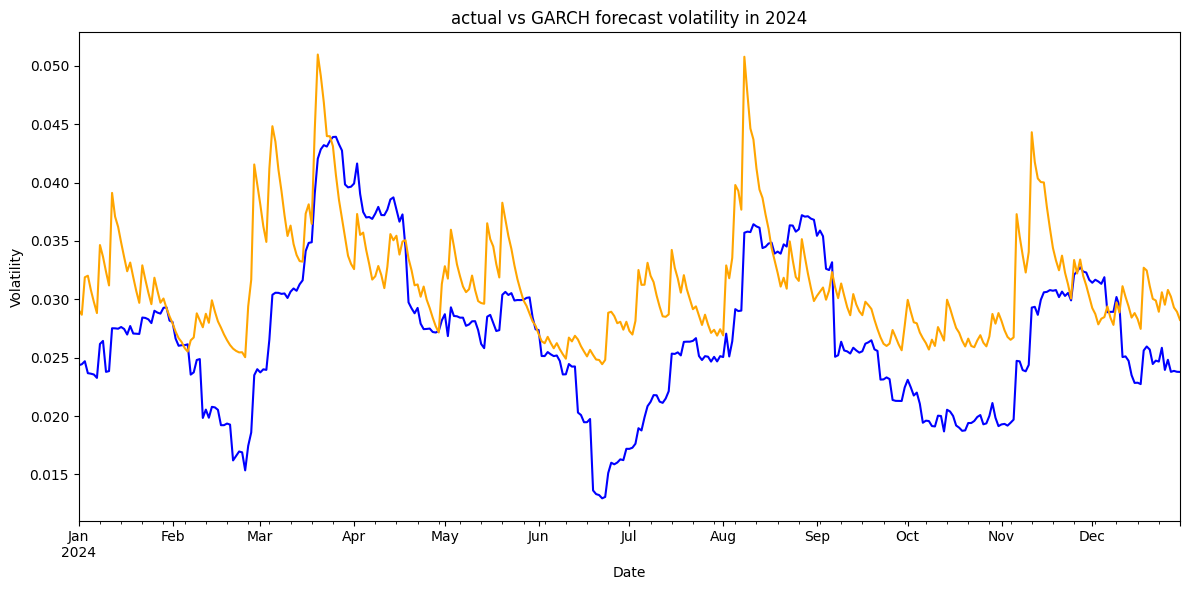

In [ ]:
# Plotting actual vs GARCH forecast volatility over test period (2024)

fig, axes = plt.subplots(figsize = (12,6))

results['actual'].plot(ax = axes, color = 'blue', label = 'Actual')
results['garch_forecast'].plot(ax = axes, color = 'orange', label = 'GARCH')
axes.set_title('actual vs GARCH forecast volatility in 2024')
axes.set_ylabel('Volatility')
axes.legend()


plt.tight_layout()
plt.show()
